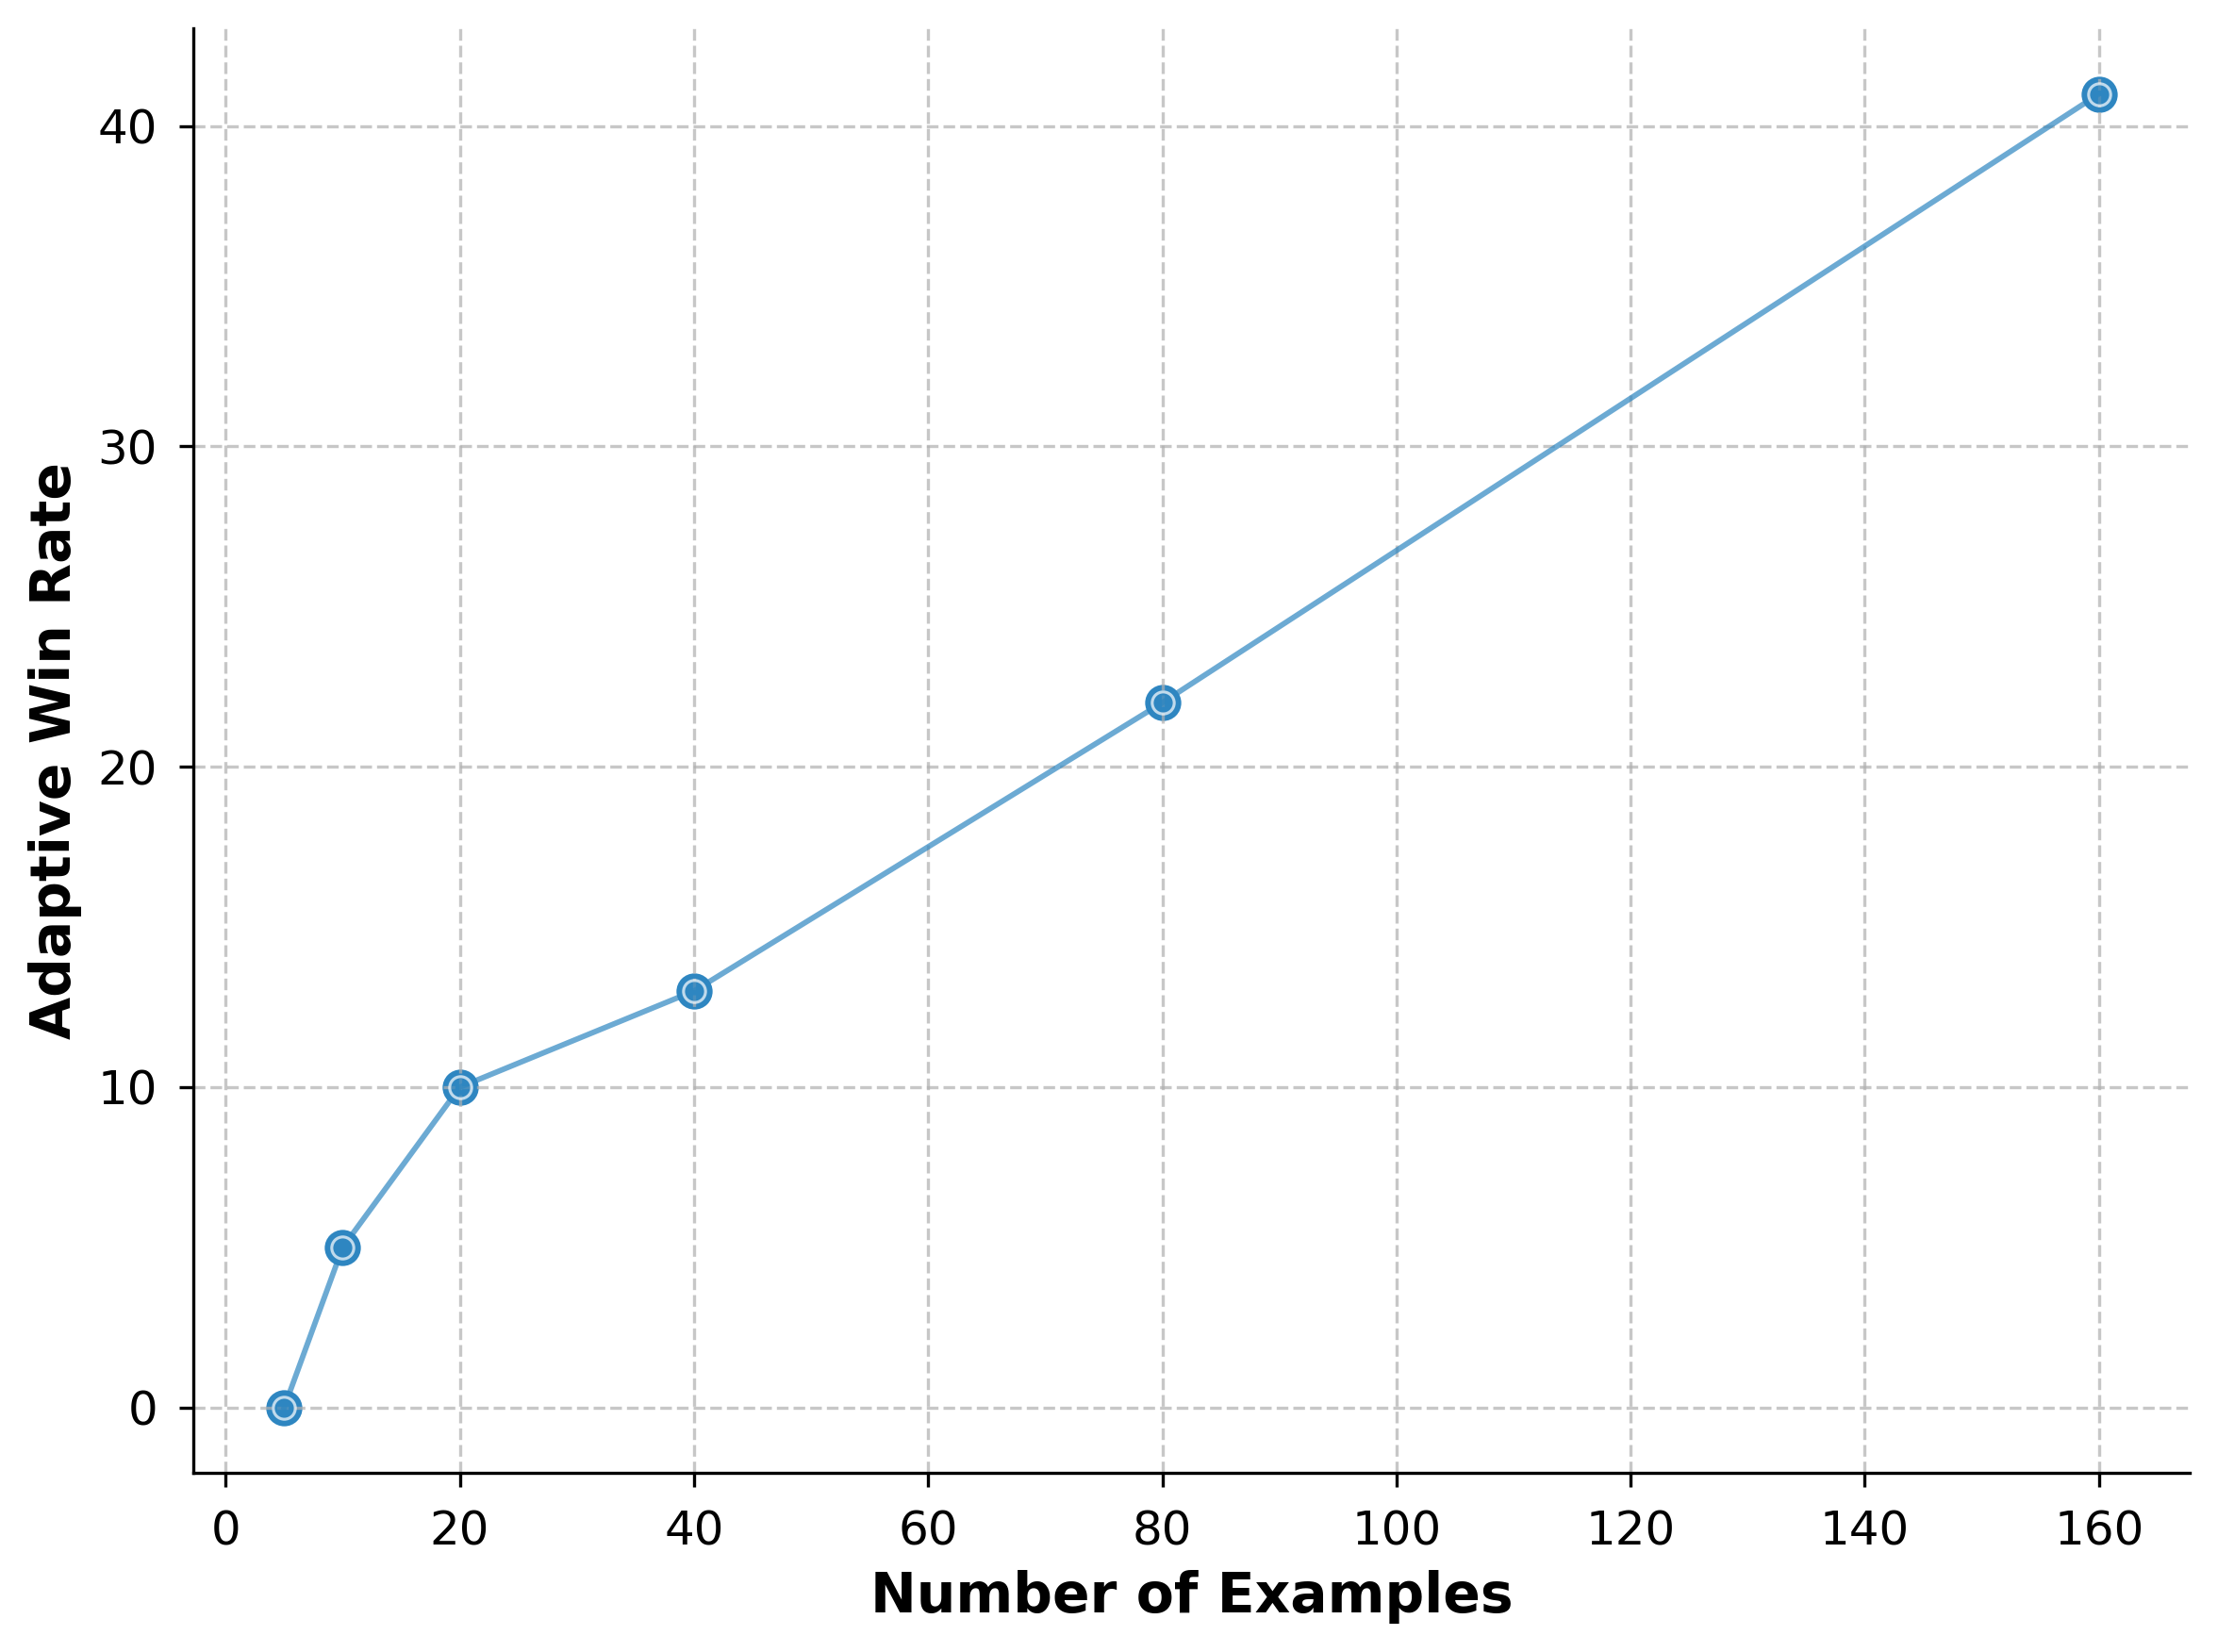

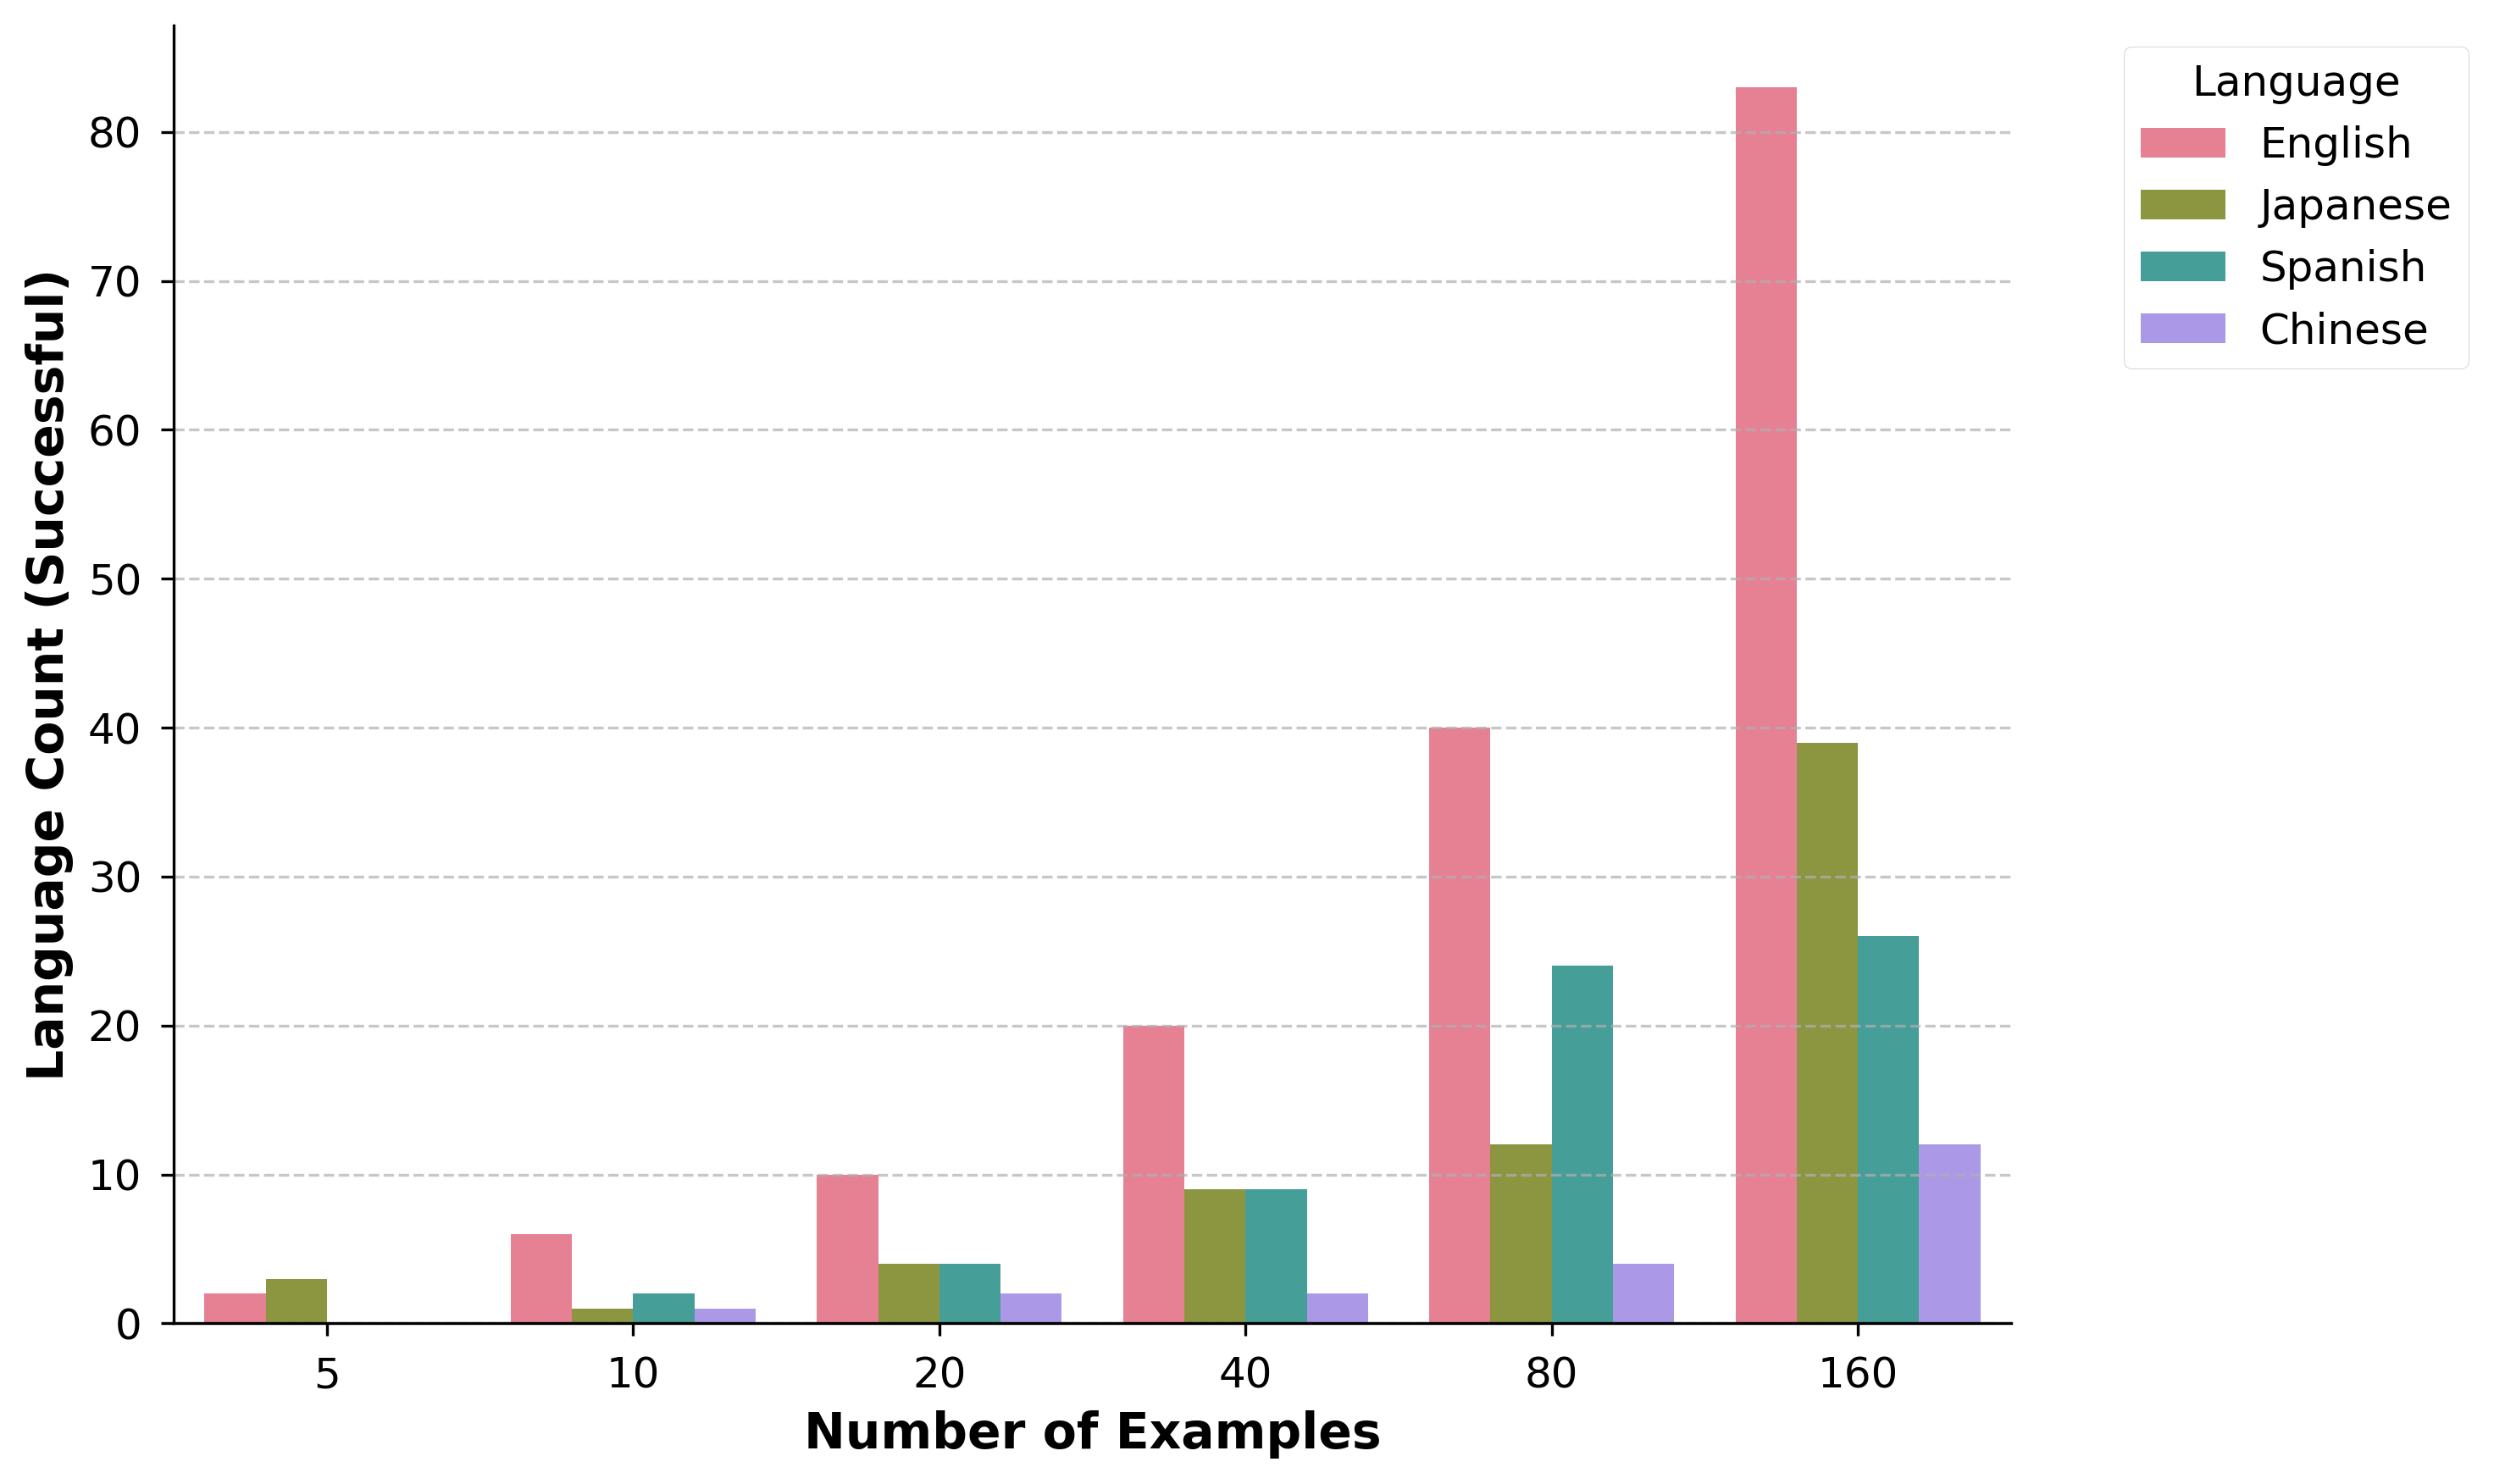

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# data from experiment_runner_politeness.py for politness_experimental_results.csv
# Use a professional style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300
})

# Define the data
data = [
    ({"English": 2, "Japanese": 3}, {"A": 3, "C": 2}, 5, 10, 0),
    ({"English": 6, "Japanese": 1, "Spanish": 2, "Chinese": 1}, {"C": 3, "A": 7}, 10, 10, 5),
    ({"Spanish": 4, "English": 10, "Japanese": 4, "Chinese": 2}, {"A": 18, "C": 2}, 20, 10, 10),
    ({"Japanese": 9, "English": 20, "Spanish": 9, "Chinese": 2}, {"A": 27, "C": 13}, 40, 10, 13),
    ({"English": 40, "Spanish": 24, "Japanese": 12, "Chinese": 4}, {"A": 51, "C": 29}, 80, 10, 22),
    ({"Spanish": 26, "Chinese": 12, "Japanese": 39, "English": 83}, {"A": 119, "C": 41}, 160, 10, 41)
]

# Convert the data to a dataframe
df = pd.DataFrame(data, columns=["judge_language_counts", "judge_choice_counts", "n_datapoints", "max_attempts", "adaptive_incorrect_count"])

# First Plot: adaptive_incorrect_count vs n_datapoints
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="n_datapoints", y="adaptive_incorrect_count", marker='o', s=100, color='#2E86C1')
sns.lineplot(data=df, x="n_datapoints", y="adaptive_incorrect_count", marker='o', color='#2E86C1', alpha=0.7)

ax.set_xlabel("Number of Examples", fontweight='bold')
ax.set_ylabel("Adaptive Win Rate", fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("adaptive_incorrect_count.png", bbox_inches='tight', dpi=300)
plt.show()

# Convert dictionary column into separate rows
language_data = []
for index, row in df.iterrows():
    for language, count in row["judge_language_counts"].items():
        language_data.append({"n_datapoints": row["n_datapoints"], "language": language, "count": count})

language_df = pd.DataFrame(language_data)

# Second Plot: Bar plot of language counts for each n_datapoints
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("husl", n_colors=len(language_df["language"].unique()))
sns.barplot(data=language_df, x="n_datapoints", y="count", hue="language", palette=palette)

ax.set_xlabel("Number of Examples", fontweight='bold')
ax.set_ylabel("Language Count (Successful)", fontweight='bold')
ax.legend(title="Language", title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("language_counts.png", bbox_inches='tight', dpi=300)
plt.show()

"Is there potentially smaller range of [something cultural]"